## Notebook to investigate elements with significant different expression to scrambled sequences
- load the data table resulting from the treat test in R
  - compared to MK scrambled sequences

In [37]:
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import re
import seaborn as sns
import yaml


# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf

# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

In [5]:
# column names
col_name = 'name'
col_header = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class' # SNP
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'
my_col_ref_base = 'tmp_ref_base'
my_col_alt_base = 'tmp_alt_base'

### General information:
- scrambled MK vs tested:
  - with alt: 61482 sequences after barcode MPRAlm
  - without alt: 23203 sequences after barcode MPRAlm
- negative neuron NP vs tested: 
  - without alt: 7124 sequences after barcode MPRAlm

In [8]:
# read table:
# mk scrambled vs tested (both sided)
element_analysis_r_result = pd.read_csv(config['files']['creating']['element_analysis_mk_scrambled_vs_tested_no_alt'], sep="\t")
element_analysis_r_result

# negative neuron np vs tested (left sided)
element_analysis_r_result = pd.read_csv(config['files']['creating']['element_analysis_np_negative_neuron_vs_tested_unique'], sep="\t")
element_analysis_r_result

,logFC,AveExpr,t,P.Value,adj.P.Val,variant_id
0,1.592724,0.776742,51.490918,0.0,0.0,cardiac_neuro_cava_random:FGF12|ENSG0000011427...
1,1.633098,0.821512,58.895243,0.0,0.0,cardiac_neuro_cava_random:RBM20|ENSG0000020386...
2,2.089245,1.281518,65.197631,0.0,0.0,cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...
3,1.891649,1.081215,64.994174,0.0,0.0,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...
4,1.765055,0.944513,62.418964,0.0,0.0,cardiac_neuro_cava_random:RERE|ENSG00000142599...
...,...,...,...,...,...,...
23785,-0.778137,-1.603027,0.000000,1.0,1.0,cardiac_neuro_cava_random:VPS13B|ENSG000001325...
23786,-0.804195,-1.620396,0.000000,1.0,1.0,cardiac_neuro_cava_random:REF_FANCM|ENSG000001...
23787,-0.808779,-1.628802,0.000000,1.0,1.0,cardiac_neuro_cava_random:NLGN4X|ENSG000001469...
23788,-0.825398,-1.645502,0.000000,1.0,1.0,cardiac_neuro_cava_random:REF_FOXP1|ENSG000001...


In [16]:
element_analysis_r_result['tmp_label'] = element_analysis_r_result['variant_id'].apply(hf.get_label)

In [17]:
element_analysis_r_result.groupby('tmp_label').size()

tmp_label
cardiac_neuro_cava_random    23790
dtype: int64

### Investigate the numbers
- how many significantly different elements are there? (2545)
- how many are positive? 
    - 1916 significant positive elements
- how many are negative? 
    - 629 significant negative elements
    - claiming that these are repressors does not make sense because we argue that these sequences are more active than the negative control and therefore active elements

In [18]:
# significant, activating, repressing
element_analysis_r_result['all'] = True
element_analysis_r_result['is_signficant'] = element_analysis_r_result['adj.P.Val'] < 0.05

element_analysis_r_result['activating_effect'] = element_analysis_r_result['logFC'] > 0
element_analysis_r_result['repressing_effect'] = element_analysis_r_result['logFC'] < 0

# significant and activating
element_analysis_r_result['is_signficant_and_activating'] = element_analysis_r_result['is_signficant'] & element_analysis_r_result['activating_effect']

# significant and repressing
element_analysis_r_result['is_signficant_and_repressing'] = element_analysis_r_result['is_signficant'] & element_analysis_r_result['repressing_effect']

In [19]:
element_analysis_r_result['is_signficant'].sum()

20896

In [20]:
element_analysis_r_result['is_signficant_and_activating'].sum(), element_analysis_r_result['is_signficant_and_repressing'].sum()

(10586, 10310)

In [21]:
element_analysis_r_result['variant_id'].nunique() # 23203

23790

In [22]:
print('Summary of numbers: ')
# Number of sequences tested
print('Number of sequences tested: ', element_analysis_r_result['variant_id'].nunique())
# Number of significant results
print('Number of significant results: ', element_analysis_r_result['is_signficant'].sum())
# Number of significant activating results
print('Number of significant activating results: ', element_analysis_r_result['is_signficant_and_activating'].sum())
# Number of significant repressing results
print('Number of significant repressing results: ', element_analysis_r_result['is_signficant_and_repressing'].sum())




# make a table with the number of significant activating and repressing elements per group
element_analysis_r_result.groupby('tmp_label').agg({'is_signficant': 'sum', 'is_signficant_and_activating': 'sum', 'is_signficant_and_repressing': 'sum'}).reset_index()

Summary of numbers: 
Number of sequences tested:  23790
Number of significant results:  20896
Number of significant activating results:  10586
Number of significant repressing results:  10310


,tmp_label,is_signficant,is_signficant_and_activating,is_signficant_and_repressing
0,cardiac_neuro_cava_random,20896,10586,10310


### Add gene set information

In [155]:
# make unique gene list from design:
# read gene list
gene_list = pd.read_csv('/home/kisa/coding/80K_MPRA/MPRA_design/resources/gene_lists/all_genes.txt', sep="\t", header=None)
gene_list.columns = ['gene_name'] # 540
gene_list = gene_list.drop_duplicates()
gene_list # 522
# write gene list
gene_list.to_csv(config['files']['creating']['design_gene_list'], sep="\t", index=False)

In [27]:
# get gene_list files:
gene_list_dir = '/home/kisa/coding/80K_MPRA/MPRA_design/resources/gene_lists'
gene_lists = os.listdir(gene_list_dir)


def get_gene_lookup_dict(gene_lists):
    """
    prepare a dict which has gene_name: (list of associated gene_sets)
    :gene_lists - list of files containing gene names and have useful names
    """
    gene_lookup_dict = defaultdict(list)
    for file in gene_lists:
        with open(os.path.join(gene_list_dir, file), 'r') as f:
            gene_list = f.read().splitlines()
            gene_list_name = file.split('.')[0]
            for gene in gene_list:
                gene_lookup_dict[gene].append(gene_list_name)
    return gene_lookup_dict

In [41]:
def get_gene_name_from_element(header):
    """Returns the gene name: cardiac_neuro_cava_random:SKI|ENSG00000157933.11|EH38E2778533_fwd_tile1-1 => SKI"""
    if hf.is_alternative(header):
        print(header)
        raise ValueError('This function is only for element sequences')

    if 'REF_' in header:
        return header.split(":REF_")[1].split('|')[0]

    elif 'ALT_' in header:
        return header.split(":ALT_")[1].split('|')[0]

    return header.split(':')[1].split('|')[0]

In [42]:

# prepare a dict which has gene_name: (tuple of associated gene_sets)
gene_lookup_dict = get_gene_lookup_dict(gene_lists=gene_lists)

In [43]:
# # get gene name from variant id
element_analysis_r_result['gene_name'] = element_analysis_r_result['variant_id'].apply(get_gene_name_from_element)
# add gene_set annotation
element_analysis_r_result['gene_set'] = element_analysis_r_result['gene_name'].apply(lambda gene: gene_lookup_dict[gene])

In [44]:
element_analysis_r_result['gene_set'].value_counts()

[neuro]             14183
[cardiac]            6548
[cava]               1469
[neuro, cardiac]      702
[random]              654
[neuro, cava]         141
[cava, cardiac]        93
Name: gene_set, dtype: int64

In [45]:
element_analysis_r_result['is_neuro'] = element_analysis_r_result['gene_set'].apply(lambda x: 'neuro' in x)
element_analysis_r_result['is_cardiac'] = element_analysis_r_result['gene_set'].apply(lambda x: 'cardiac' in x)
element_analysis_r_result['is_cava'] = element_analysis_r_result['gene_set'].apply(lambda x: 'cava' in x)
element_analysis_r_result['is_random'] = element_analysis_r_result['gene_set'].apply(lambda x: 'random' in x)


In [46]:
# get the number of significant activating and repressing elements per gene_set (gene_set is a list) => use is_neuro, is_cardiac, is_cava, is_random
element_analysis_r_result.groupby(['is_neuro', 'is_cardiac', 'is_cava', 'is_random']).agg({'is_signficant': 'sum', 'is_signficant_and_activating': 'sum', 'is_signficant_and_repressing': 'sum'}).reset_index()

,is_neuro,is_cardiac,is_cava,is_random,is_signficant,is_signficant_and_activating,is_signficant_and_repressing
0,False,False,False,True,581,301,280
1,False,False,True,False,1282,623,659
2,False,True,False,False,5727,2853,2874
3,False,True,True,False,84,42,42
4,True,False,False,False,12488,6426,6062
5,True,False,True,False,126,60,66
6,True,True,False,False,608,281,327


In [17]:
element_analysis_r_result['is_signiciant_and_neuro'] = element_analysis_r_result['is_signficant'] & element_analysis_r_result['is_neuro']
element_analysis_r_result['is_signiciant_and_cardiac'] = element_analysis_r_result['is_signficant'] & element_analysis_r_result['is_cardiac']
element_analysis_r_result['is_signiciant_and_cava'] = element_analysis_r_result['is_signficant'] & element_analysis_r_result['is_cava']
element_analysis_r_result['is_signiciant_and_random'] = element_analysis_r_result['is_signficant'] & element_analysis_r_result['is_random']

# significant group and activating
element_analysis_r_result['is_signiciant_and_neuro_activating'] = element_analysis_r_result['is_signficant'] & element_analysis_r_result['is_neuro'] & element_analysis_r_result['activating_effect']
element_analysis_r_result['is_signiciant_and_cardiac_activating'] = element_analysis_r_result['is_signficant'] & element_analysis_r_result['is_cardiac'] & element_analysis_r_result['activating_effect']
element_analysis_r_result['is_signiciant_and_cava_activating'] = element_analysis_r_result['is_signficant'] & element_analysis_r_result['is_cava'] & element_analysis_r_result['activating_effect']
element_analysis_r_result['is_signiciant_and_random_activating'] = element_analysis_r_result['is_signficant'] & element_analysis_r_result['is_random'] & element_analysis_r_result['activating_effect']

# significant group and repressing
element_analysis_r_result['is_signiciant_and_neuro_repressing'] = element_analysis_r_result['is_signficant'] & element_analysis_r_result['is_neuro'] & element_analysis_r_result['repressing_effect']
element_analysis_r_result['is_signiciant_and_cardiac_repressing'] = element_analysis_r_result['is_signficant'] & element_analysis_r_result['is_cardiac'] & element_analysis_r_result['repressing_effect']
element_analysis_r_result['is_signiciant_and_cava_repressing'] = element_analysis_r_result['is_signficant'] & element_analysis_r_result['is_cava'] & element_analysis_r_result['repressing_effect']
element_analysis_r_result['is_signiciant_and_random_repressing'] = element_analysis_r_result['is_signficant'] & element_analysis_r_result['is_random'] & element_analysis_r_result['repressing_effect']


In [18]:
# compute proportions of significant being associated to neuro
print('Neuro:')
print('Proportion of significant: ', round(element_analysis_r_result['is_signiciant_and_neuro'].sum() / element_analysis_r_result['is_signficant'].sum(),3))
print('Proportion of significant activators: ', round(element_analysis_r_result['is_signiciant_and_neuro_activating'].sum() / element_analysis_r_result['is_signficant_and_activating'].sum(),3))
print('Proportion of significant repressors: ', round(element_analysis_r_result['is_signiciant_and_neuro_repressing'].sum() / element_analysis_r_result['is_signficant_and_repressing'].sum(),3))

# compute proportions of significant being associated to cardiac
print('Cardiac:')
print('Proportion of significant: ', round(element_analysis_r_result['is_signiciant_and_cardiac'].sum() / element_analysis_r_result['is_signficant'].sum(),3))
print('Proportion of significant activators: ', round(element_analysis_r_result['is_signiciant_and_cardiac_activating'].sum() / element_analysis_r_result['is_signficant_and_activating'].sum(),3))
print('Proportion of significant repressors: ', round(element_analysis_r_result['is_signiciant_and_cardiac_repressing'].sum() / element_analysis_r_result['is_signficant_and_repressing'].sum(),3))

# compute proportions of significant being associated to cava
print('Cava:')
print('Proportion of significant: ', round(element_analysis_r_result['is_signiciant_and_cava'].sum() / element_analysis_r_result['is_signficant'].sum(),3))
print('Proportion of significant activators: ', round(element_analysis_r_result['is_signiciant_and_cava_activating'].sum() / element_analysis_r_result['is_signficant_and_activating'].sum(),3))
print('Proportion of significant repressors: ', round(element_analysis_r_result['is_signiciant_and_cava_repressing'].sum() / element_analysis_r_result['is_signficant_and_repressing'].sum(),3))

# compute proportions of significant being associated to random
print('Random:')
print('Proportion of significant: ', round(element_analysis_r_result['is_signiciant_and_random'].sum() / element_analysis_r_result['is_signficant'].sum(),5))
print('Proportion of significant activators: ', round(element_analysis_r_result['is_signiciant_and_random_activating'].sum() / element_analysis_r_result['is_signficant_and_activating'].sum(),5))
print('Proportion of significant repressors: ', round(element_analysis_r_result['is_signiciant_and_random_repressing'].sum() / element_analysis_r_result['is_signficant_and_repressing'].sum(),5))



Neuro:
Proportion of significant:  0.632
Proportion of significant activators:  0.639
Proportion of significant repressors:  0.628
Cardiac:
Proportion of significant:  0.308
Proportion of significant activators:  0.3
Proportion of significant repressors:  0.313
Cava:
Proportion of significant:  0.071
Proportion of significant activators:  0.067
Proportion of significant repressors:  0.073
Random:
Proportion of significant:  0.02825
Proportion of significant activators:  0.02988
Proportion of significant repressors:  0.02739


In [19]:
# investigate the proportion of significant activating and repressing elements per significant elements per gene set
# for neuro
print('Neuro: to itself:')
print('Proportion of significant: ', round(element_analysis_r_result['is_signiciant_and_neuro'].sum() / element_analysis_r_result['is_neuro'].sum(),3))
print('Proportion of significant activators: ', round(element_analysis_r_result['is_signiciant_and_neuro_activating'].sum() / element_analysis_r_result['is_signiciant_and_neuro'].sum(),3))
print('Proportion of significant repressors: ', round(element_analysis_r_result['is_signiciant_and_neuro_repressing'].sum() / element_analysis_r_result['is_signiciant_and_neuro'].sum(),3))

# for cardiac
print('Cardiac: to itself:')
print('Proportion of significant: ', round(element_analysis_r_result['is_signiciant_and_cardiac'].sum() / element_analysis_r_result['is_cardiac'].sum(),3))
print('Proportion of significant activators: ', round(element_analysis_r_result['is_signiciant_and_cardiac_activating'].sum() / element_analysis_r_result['is_signiciant_and_cardiac'].sum(),3))
print('Proportion of significant repressors: ', round(element_analysis_r_result['is_signiciant_and_cardiac_repressing'].sum() / element_analysis_r_result['is_signiciant_and_cardiac'].sum(),3))

# for cava
print('Cava: to itself:')
print('Proportion of significant: ', round(element_analysis_r_result['is_signiciant_and_cava'].sum() / element_analysis_r_result['is_cava'].sum(),3))
print('Proportion of significant activators: ', round(element_analysis_r_result['is_signiciant_and_cava_activating'].sum() / element_analysis_r_result['is_signiciant_and_cava'].sum(),3))
print('Proportion of significant repressors: ', round(element_analysis_r_result['is_signiciant_and_cava_repressing'].sum() / element_analysis_r_result['is_signiciant_and_cava'].sum(),3))

# for random
print('Random: to itself:')
print('Proportion of significant: ', round(element_analysis_r_result['is_signiciant_and_random'].sum() / element_analysis_r_result['is_random'].sum(),3))
print('Proportion of significant activators: ', round(element_analysis_r_result['is_signiciant_and_random_activating'].sum() / element_analysis_r_result['is_signiciant_and_random'].sum(),3))
print('Proportion of significant repressors: ', round(element_analysis_r_result['is_signiciant_and_random_repressing'].sum() / element_analysis_r_result['is_signiciant_and_random'].sum(),3))


Neuro: to itself:
Proportion of significant:  0.883
Proportion of significant activators:  0.351
Proportion of significant repressors:  0.649
Cardiac: to itself:
Proportion of significant:  0.883
Proportion of significant activators:  0.338
Proportion of significant repressors:  0.662
Cava: to itself:
Proportion of significant:  0.881
Proportion of significant activators:  0.328
Proportion of significant repressors:  0.672
Random: to itself:
Proportion of significant:  0.898
Proportion of significant activators:  0.367
Proportion of significant repressors:  0.633


In [ ]:
def plot_significant_count_per_gene(gene_name_significant_counts, count_column_name='significant_variant_count', type_of_count='Variant', output_path=None):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd

    # Assuming your data is in a DataFrame called 'df'
    # If it's not, you can create it like this:
    # df = pd.DataFrame({'gene_name': [...], count_column_name: [...]})

    # Sort the DataFrame by count_column_name in descending order
    df_sorted = gene_name_significant_counts.sort_values('gene_name', ascending=True)

    # Create the bar plot
    plt.figure(figsize=(12, 6))
    plot = sns.barplot(x='gene_name', y=count_column_name, data=df_sorted)

    # Customize the plot
    plt.xlabel(f'Gene Names (n={df_sorted["gene_name"].nunique()})')
    plt.ylabel(f'Significant {type_of_count} Count (n={int(df_sorted[count_column_name].sum())})')
    plt.title(f'Significant {type_of_count} Count associated to Gene')
    plt.xticks(rotation=90)  # Rotate x-axis labels for better readability

    # Add value labels on top of each bar
    for i, v in enumerate(df_sorted[count_column_name]):
        plt.text(i, v, str(int(v)), ha='center', va='bottom')

    # Adjust layout and display the plot
    plt.tight_layout()

    fig = plot.get_figure()
    # store to path
    if output_path != None:
        fig.savefig(output_path)
    plt.show()


### Prepare element id, sequence, logFC (BCALM) => Model predicting logFC from sequence
- metadata table + bcalm logFC
- metadata file nicht vollständig: 
    - 74 tested sequences which we have measurements are missing (70 have "ALT" in the name) but 4 refs: 
    - "['cardiac_neuro_cava_random:REF_WDFY3|ENSG00000163625.17|EH38E2309079_rev_tile1-1',
 'cardiac_neuro_cava_random:REF_GIGYF2|ENSG00000204120.16|EH38E3407187_fwd_tile1-1',
 'cardiac_neuro_cava_random:REF_FBXO28|ENSG00000143756.12|EH38E2868786_fwd_tile1-1',
 'cardiac_neuro_cava_random:REF_GATAD1|ENSG00000157259.8|EH38E3785709_fwd_tile1-1']" 

In [12]:
import ast

# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x

In [13]:
element_analysis_r_result.head()
element_analysis_bcalm_result = element_analysis_r_result.copy()
# rename: variant_id -> col_name
element_analysis_bcalm_result = element_analysis_bcalm_result.rename(columns={'variant_id': col_name})

# read metadata information and get all the sequences from the variant_id
tested_metadata_datafreeze = pd.read_csv(config['files']['creating']['datafreeze_table'], sep="\t", low_memory=False)
tested_metadata_datafreeze

# list columns col_variant_class, col_variant_pos, col_SPDI, col_allele,
list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]
# Apply the safe_eval function to the specified columns
for col in list_columns:
    tested_metadata_datafreeze[col] = tested_metadata_datafreeze[col].apply(safe_eval)

In [18]:
print(tested_metadata_datafreeze.shape[0])
tested_metadata_datafreeze[col_name].nunique()

73846


73846

In [29]:
# merge the metadata with the element analysis results
print(element_analysis_bcalm_result.shape[0])
print(element_analysis_bcalm_result[col_name].nunique())
element_analysis_bcalm_result_seq = element_analysis_bcalm_result.merge(tested_metadata_datafreeze, on=col_name, how='left')
# some are na:
not_found_elements_in_datafreeze = element_analysis_bcalm_result_seq.loc[element_analysis_bcalm_result_seq[col_sequence].isna()]
print("Not found elements from data freeze: ", not_found_elements_in_datafreeze.shape[0])

print('Number of elements containing "ALT_" in the name: ', not_found_elements_in_datafreeze[col_name].str.contains('ALT_').sum())

not_found_elements_in_datafreeze.loc[~not_found_elements_in_datafreeze[col_name].str.contains('ALT_')][col_name].to_list()
# element_analysis_bcalm_result_seq.loc[element_analysis_bcalm_result_seq[col_sequence].isna()][col_name].str.contains('ALT_').sum() # 70
# print(element_analysis_bcalm_result_seq.shape[0])
# print(element_analysis_bcalm_result_seq[col_sequence].nunique())

23790
23790
Not found elements from data freeze:  74
Number of elements containing "ALT_" in the name:  70


['cardiac_neuro_cava_random:REF_WDFY3|ENSG00000163625.17|EH38E2309079_rev_tile1-1',
 'cardiac_neuro_cava_random:REF_GIGYF2|ENSG00000204120.16|EH38E3407187_fwd_tile1-1',
 'cardiac_neuro_cava_random:REF_FBXO28|ENSG00000143756.12|EH38E2868786_fwd_tile1-1',
 'cardiac_neuro_cava_random:REF_GATAD1|ENSG00000157259.8|EH38E3785709_fwd_tile1-1']

In [38]:
# use design file
no_collsion_design_df = hf.fasta_to_dataframe(config['files']['final_design']['third_design_fasta_no_collisions'])
# rename first column to col_name
no_collsion_design_df = no_collsion_design_df.rename(columns={no_collsion_design_df.columns[0]: col_name})

print(element_analysis_bcalm_result.shape[0])
print(element_analysis_bcalm_result[col_name].nunique())
element_analysis_bcalm_result_seq = element_analysis_bcalm_result.merge(no_collsion_design_df, on=col_name, how='left')
# some are na:
not_found_elements_in_datafreeze = element_analysis_bcalm_result_seq.loc[element_analysis_bcalm_result_seq[col_sequence].isna()]
print("Not found elements from data freeze: ", not_found_elements_in_datafreeze.shape[0])

print('Number of elements containing "ALT_" in the name: ', not_found_elements_in_datafreeze[col_name].str.contains('ALT_').sum())

not_found_elements_in_datafreeze

# only important columns: name, sequence, logfc
element_analysis_bcalm_result_seq = element_analysis_bcalm_result_seq[[col_name, col_sequence, 'logFC']]

# write to element analysis results directory:
element_analysis_bcalm_result_seq.to_csv(os.path.join(config['files']['creating']['element_activity_prediction_data_tested_dir'], f'tested_sequences_only_{element_analysis_bcalm_result_seq.shape[0]}.tsv'), sep="\t", index=False)


23790
23790
Not found elements from data freeze:  0
Number of elements containing "ALT_" in the name:  0


### Focus on neuro elements

In [137]:
# what is the proportion of neuro elements which are open in neuro
meta_data_file = pd.read_csv(config['files']['creating']['datafreeze_table'], sep="\t", low_memory=False)

# read columns from tsv
# list columns col_variant_class, col_variant_pos, col_SPDI, col_allele,
list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]
# Apply the safe_eval function to the specified columns
for col in list_columns:
    meta_data_file[col] = meta_data_file[col].apply(safe_eval)

In [65]:
### Focus on neuro elements:
neuro_element_analysis_result = element_analysis_r_result.loc[element_analysis_r_result['is_neuro']]
neuro_element_analysis_result
print('Number of neuro associated results: ', neuro_element_analysis_result['variant_id'].nunique()) # 15026

significant_neuro_element_analysis_result = neuro_element_analysis_result.loc[neuro_element_analysis_result['is_signficant']]
# read design file
design_file_df = hf.fasta_to_dataframe(config['files']['final_design']['design_fasta'])
# add sequence:
significant_neuro_element_analysis_result = pd.merge(significant_neuro_element_analysis_result, design_file_df, left_on='variant_id', right_on='header', how='left')
# significant_neuro_element_analysis_result['sequence'].isna().sum() # 0
# drop variant_id
significant_neuro_element_analysis_result.drop(columns=['variant_id'], inplace=True)

# number of significantly active elements
print('Number of significant neuro associated results: ', significant_neuro_element_analysis_result['header'].nunique()) # 13222
# number of associated genes
print('number of associated genes: ', significant_neuro_element_analysis_result['gene_name'].nunique()) # 305 (48 in design file)

# find top 95 percentile in terms of activity (logFC) of significant results
highly_active_elements_neuro = significant_neuro_element_analysis_result.loc[significant_neuro_element_analysis_result['logFC'] > significant_neuro_element_analysis_result['logFC'].quantile(0.95)]
print('Number of highly active neuro associated results: ', highly_active_elements_neuro['header'].nunique()) # 662

low_activity_elements_neuro = significant_neuro_element_analysis_result.loc[significant_neuro_element_analysis_result['logFC'] < significant_neuro_element_analysis_result['logFC'].quantile(0.05)]
print('Number of low active neuro associated results: ', low_activity_elements_neuro['header'].nunique()) # 662

# write as fasta
high_activitiy_element_sequences = f'/home/kisa/coding/80K_MPRA/element_analysis_output/tfbs_enrichment/highly_active_neuro_elements_{highly_active_elements_neuro.shape[0]}.fa'
hf.write_fasta(highly_active_elements_neuro, high_activitiy_element_sequences)

low_activity_element_sequences = f'/home/kisa/coding/80K_MPRA/element_analysis_output/tfbs_enrichment/low_activity_neuro_elements_{low_activity_elements_neuro.shape[0]}.fa'
hf.write_fasta(low_activity_elements_neuro, low_activity_element_sequences)


Number of neuro associated results:  15026
Number of significant neuro associated results:  13222
number of associated genes:  305
Number of highly active neuro associated results:  662
Number of low active neuro associated results:  662


True

In [144]:
significant_elements.columns

Index(['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'variant_id',
       'tmp_label', 'all', 'is_signficant', 'activating_effect',
       'repressing_effect', 'is_signficant_and_activating',
       'is_signficant_and_repressing', 'gene_name', 'gene_set', 'is_neuro',
       'is_cardiac', 'is_cava', 'is_random'],
      dtype='object')

In [148]:
# only open elements
meta_data_file.columns
open_ngn2_wtc11_atac_np = meta_data_file[meta_data_file['tmp_open_NGN2_WTC11_NP']]

significant_elements = element_analysis_r_result.loc[element_analysis_r_result['is_signficant']]

open_h1_neuro_dnase = meta_data_file[meta_data_file['tmp_open_h1_neuro_dnase_screen']] # 20896
print('All significant elements: ', significant_elements.shape[0]) # 20896
print('All significant neuro associated elements: ', significant_neuro_element_analysis_result.shape[0]) # 13222
significant_elements_open_h1 = significant_elements.loc[significant_elements['variant_id'].isin(open_h1_neuro_dnase['header'])]
significant_elements_neuro_open_h1 = significant_neuro_element_analysis_result.loc[significant_neuro_element_analysis_result['header'].isin(open_h1_neuro_dnase['header'])]
print('All significant elements overlapping open chromatin in neuro: ', significant_elements_open_h1.shape[0]) # 1150
print('All significant neuro elements overlapping open chromatin in neuro: ', significant_elements_neuro_open_h1.shape[0]) # 671
significant_elements_open_h1.shape[0] # 671

print('Proportion of significant elements overlapping open chromatin in neuro: ', significant_elements_open_h1.shape[0] / significant_elements.shape[0]) # 0.055
print('Proportion of significant neuro elements overlapping open chromatin in neuro: ', significant_elements_neuro_open_h1.shape[0] / significant_neuro_element_analysis_result.shape[0]) # 0.051

All significant elements:  20896
All significant neuro associated elements:  13222
All significant elements overlapping open chromatin in neuro:  1150
All significant neuro elements overlapping open chromatin in neuro:  671
Proportion of significant elements overlapping open chromatin in neuro:  0.055034456355283305
Proportion of significant neuro elements overlapping open chromatin in neuro:  0.050748752079866885


In [67]:
# call fimo using the TFBS motif set
#### FIMO commands:
motif_set = config['files']['creating']['local_h12core_tf_less_redundant_motif_set']
# motif_set = '/data/cephfs-2/unmirrored/groups/kircher/Kaikkonen_2023/filesFromMinnaKaikkonen/github_repo/STARseqCNN/JASPAR2022_CORE_vertebrates_non-redundant_pfms_meme_nice.txt'
#! remember changing motif set name
motif_set_name = 'H12CORE_TF_LESS_REDUNDANT'
neuro_element_output = config['files']['creating']['fimo_neuro_element_output_dir']

fimo_output_name_high = "fimo_neuro_elements_high_significant_neuro_NP"
fimo_output_path = os.path.join(neuro_element_output, fimo_output_name_high)

# example: would require to install meme in current environment
# !conda activate meme;
!fimo --max-stored-scores 1000000 --o {fimo_output_path} {motif_set} {high_activitiy_element_sequences};
print("Fimo output is saved at: ", fimo_output_path)
fimo_output_name_low = "fimo_neuro_elements_low_significant_neuro_NP"
fimo_output_path = os.path.join(neuro_element_output, fimo_output_name_low)
!fimo --max-stored-scores 1000000 --o {fimo_output_path} {motif_set} {low_activity_element_sequences};
print("Fimo output is saved at: ", fimo_output_path)

Using motif +AHR.H12CORE.0.P.B of width 10.
Using motif -AHR.H12CORE.0.P.B of width 10.
Finding best site passing the output threshold in each of the 662 sequences.
Found a best site in 662 sequences.
Computing q-values.
# Computing q-values.
#   Estimating pi_0 from a uniformly sampled set of 10000 p-values.
#   Estimating pi_0.
# Minimal pi_zero = 0.989342
#   Estimated pi_0=0.997889
Using motif +ALX1.H12CORE.0.SM.B of width 20.
Using motif -ALX1.H12CORE.0.SM.B of width 20.
Finding best site passing the output threshold in each of the 662 sequences.
Found a best site in 38 sequences.
Computing q-values.
# Computing q-values.
#   Estimating pi_0 from a uniformly sampled set of 10000 p-values.
#   Estimating pi_0.
# Minimal pi_zero = 0.999282
#   Estimated pi_0=1
Using motif +ANDR.H12CORE.1.S.C of width 8.
Using motif -ANDR.H12CORE.1.S.C of width 8.
Finding best site passing the output threshold in each of the 662 sequences.
Found a best site in 46 sequences.
Computing q-values.
# Comp

In [82]:
high_motif_count_fimo

NameError: name 'high_motif_count_fimo' is not defined

In [118]:
significant_threshold = 0.01

Number of motifs in high activity:  70
Number of motifs in low activity:  48


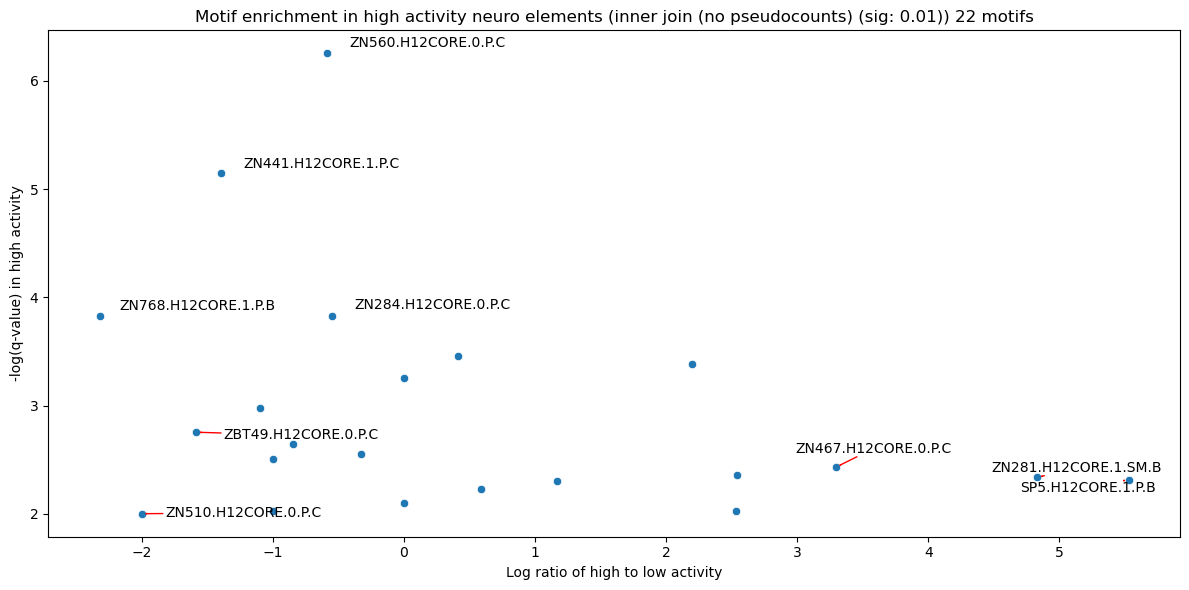

0        SP5.H12CORE.1.P.B
1      ZBT49.H12CORE.0.P.C
5     ZN281.H12CORE.1.SM.B
6      ZN284.H12CORE.0.P.C
9      ZN441.H12CORE.1.P.C
10     ZN467.H12CORE.0.P.C
11     ZN510.H12CORE.0.P.C
14     ZN560.H12CORE.0.P.C
17     ZN768.H12CORE.1.P.B
Name: motif_id, dtype: object

In [119]:
# read fimo output
high_fimo_output = os.path.join(neuro_element_output, "fimo_neuro_elements_high_significant_neuro_NP", "fimo.tsv")
low_fimo_output = os.path.join(neuro_element_output, "fimo_neuro_elements_low_significant_neuro_NP", "fimo.tsv")
high_fimo_results_neuro = pd.read_csv(high_fimo_output, sep="\t")
low_fimo_results_neuro = pd.read_csv(low_fimo_output, sep="\t")
# filter for significant results
significant_high_fimo_motifs = high_fimo_results_neuro.loc[high_fimo_results_neuro['q-value'] < significant_threshold]
significant_low_fimo_motifs = low_fimo_results_neuro.loc[low_fimo_results_neuro['q-value'] < significant_threshold]

# make high motif count table
high_motif_count_table = significant_high_fimo_motifs.groupby('motif_id').agg({'motif_id': 'count', 'q-value': ['mean', 'median', 'sum']}).reset_index()
high_motif_count_table.columns = ['motif_id', 'high_activity_count', 'q-value_mean', 'q-value_median', 'q-value_sum']
high_motif_count_table

# make low motif count table
low_motif_count_table = significant_low_fimo_motifs.groupby('motif_id').agg({'motif_id': 'count', 'q-value': ['mean', 'median', 'sum']}).reset_index()
low_motif_count_table.columns = ['motif_id', 'low_activity_count', 'q-value_mean', 'q-value_median', 'q-value_sum']
low_motif_count_table
print('Number of motifs in high activity: ', high_motif_count_table.shape[0])
print('Number of motifs in low activity: ', low_motif_count_table.shape[0])

# # make inner join
motif_count_table = pd.merge(high_motif_count_table, low_motif_count_table, on='motif_id', how='inner', suffixes=('_high', '_low'))
motif_count_table
# add column with log ratio of high to low activity
motif_count_table['log_ratio'] = np.log2(motif_count_table['high_activity_count'] / motif_count_table['low_activity_count'])
motif_count_table
# 22 motifs overlap
# goal: for each motif: ratio of high to low activity (required: number of findings in high and low activity elements)
# plot the log ratio and the log(q-value) and annotate the motifs of the top 5 highest and top 3 lowest ratios
motif_count_table['log(q-value)_high'] = -np.log10(motif_count_table['q-value_sum_high'])
motif_count_table['log(q-value)_high'] = -np.log10(motif_count_table['q-value_median_high'])

# plot
plt.figure(figsize=(12, 6))
plot = sns.scatterplot(x='log_ratio', y='log(q-value)_high', data=motif_count_table)
plt.xlabel('Log ratio of high to low activity')
plt.ylabel('-log(q-value) in high activity')
plt.title(f'Motif enrichment in high activity neuro elements (inner join (no pseudocounts) (sig: {significant_threshold})) {motif_count_table.shape[0]} motifs')
# annotate top 5 highest and top 3 lowest ratios with motif_id
# top 5 highest
top_highest_ratio = motif_count_table.nlargest(3, 'log_ratio')
top_lowest_ratio = motif_count_table.nsmallest(3, 'log_ratio')
top_highest_q = motif_count_table.nlargest(3, 'log(q-value)_high')

annotations = motif_count_table['motif_id'].isin(top_highest_ratio['motif_id']) | motif_count_table['motif_id'].isin(top_highest_q['motif_id']) | (motif_count_table['log(q-value)_high'] > 50) | motif_count_table['motif_id'].isin(top_lowest_ratio['motif_id'])
# restrict overlapping annotations
from adjustText import adjust_text
texts = []
for i, txt in enumerate(motif_count_table[annotations]['motif_id']):
    texts.append(plt.text(motif_count_table[annotations]['log_ratio'].iloc[i], motif_count_table[annotations]['log(q-value)_high'].iloc[i], txt))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))
plt.tight_layout()
plt.show()

motif_count_table[annotations]['motif_id']





([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, 'ZN768.H12CORE.1.P.B'),
  Text(1, 0, 'ZN510.H12CORE.0.P.C'),
  Text(2, 0, 'ZBT49.H12CORE.0.P.C'),
  Text(3, 0, 'ZN441.H12CORE.1.P.C'),
  Text(4, 0, 'ZN121.H12CORE.0.P.B'),
  Text(5, 0, 'ZN135.H12CORE.0.P.C'),
  Text(6, 0, 'ZNF16.H12CORE.0.P.C'),
  Text(7, 0, 'ZN791.H12CORE.0.P.C'),
  Text(8, 0, 'ZN560.H12CORE.0.P.C'),
  Text(9, 0, 'ZN284.H12CORE.0.P.C'),
  Text(10, 0, 'ZN362.H12CORE.0.P.C'),
  Text(11, 0, 'ZN566.H12CORE.0.P.C'),
  Text(12, 0, 'ZN787.H12CORE.0.M.C'),
  Text(13, 0, 'ZN436.H12CORE.0.P.C'),
  Text(14, 0, 'ZN548.H12CORE.0.P.B'),
  Text(15, 0, 'ZN823.H12CORE.0.P.C'),
  Text(16, 0, 'ZN540.H12CORE.0.P.C'),
  Text(17, 0, 'ZN613.H12CORE.0.P.C'),
  Text(18, 0, 'ZN132.H12CORE.0.P.C'),
  Text(19, 0, 'ZN467.H12CORE.0.P.C'),
  Text(20, 0, 'ZN281.H12CORE.1.SM.B'),
  Text(21, 0, 'SP5.H12CORE.1.P.B')])

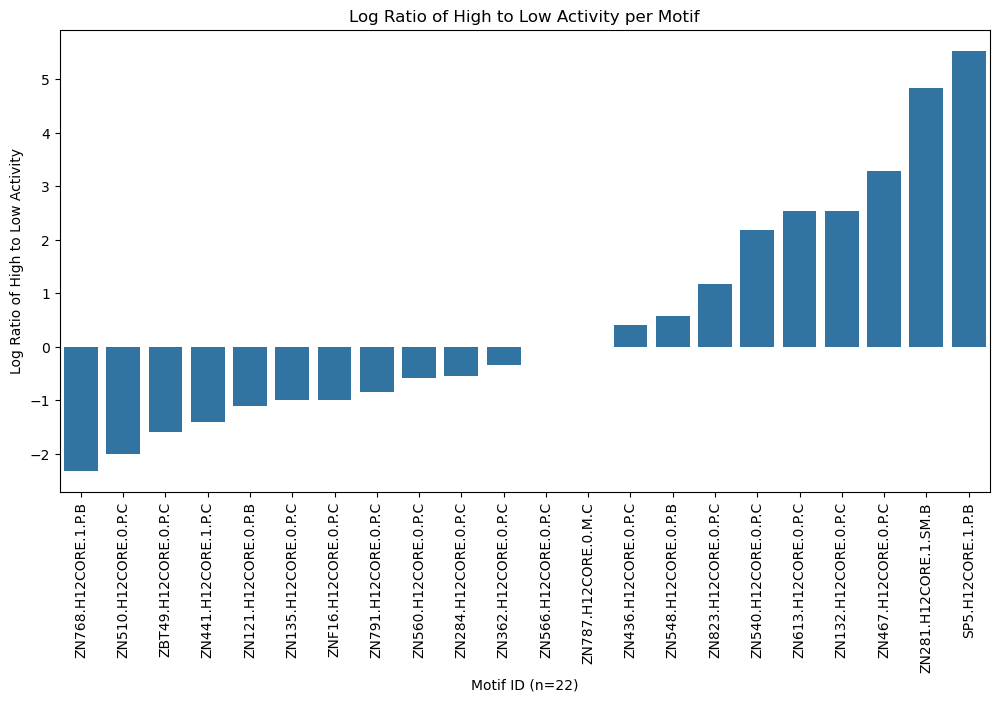

In [81]:
# sort by log ratio
motif_count_table.sort_values('log_ratio', ascending=True, inplace=True)
# plot
plt.figure(figsize=(12, 6))
plot = sns.barplot(x='motif_id', y='log_ratio', data=motif_count_table)
# Customize the plot
plt.xlabel(f'Motif ID (n={motif_count_table.shape[0]})')
plt.ylabel(f'Log Ratio of High to Low Activity')
plt.title(f'Log Ratio of High to Low Activity per Motif')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability

#### Annotate with gene information

In [133]:
h12core_annotations = pd.read_json(config['files']['creating']['h12core_annotations'], lines=True)
h12core_annotations.columns = [col + "_h12core" for col in h12core_annotations.columns]
h12core_annotations
if h12core_annotations['name_h12core'].nunique() != h12core_annotations.shape[0]:
    raise ValueError('Check for duplicates in h12core annotations')

In [132]:
motif_count_table_annotations = pd.merge(motif_count_table, h12core_annotations, left_on='motif_id', right_on='name_h12core', how='left')
motif_count_table_annotations['masterlist_info_h12core'].isna().sum() # 0

motif_count_table_annotations['masterlist_info_h12core'].to_list()
motif_count_table_annotations # 22

,motif_id,high_activity_count,q-value_mean_high,q-value_median_high,q-value_sum_high,low_activity_count,q-value_mean_low,q-value_median_low,q-value_sum_low,log_ratio,...,num_words_h12core,consensus_h12core,gc_content_h12core,information_content_total_h12core,information_content_per_base_h12core,pcm_h12core,pwm_h12core,pfm_h12core,metrics_summary_h12core,standard_thresholds_h12core
0,SP5.H12CORE.1.P.B,323,0.005024,4.820000e-03,1.622692,7,0.005534,4.440000e-03,0.038740,5.528035,...,994,vddRRvddRRvdRRGGGMGGRGvdv,0.662012,16.003357,0.640134,"[[227.0, 155.0, 478.0, 134.0], [249.0, 96.0, 4...","[[-0.08983994139032801, -0.467866800485473, 0....","[[0.22837022132796703, 0.15593561368209202, 0....",{'ChIP-Seq': {'overall': {'centrimo': {'log_ev...,"{'0.001': 2.892859999999999, '0.0005': 4.02145..."
1,ZBT49.H12CORE.0.P.C,5,0.002976,1.760000e-03,0.014882,15,0.000931,2.880000e-04,0.013961,-1.584963,...,73,GWGACCdKMCMKGMvRAARKRRb,0.548541,19.987505,0.869022,"[[8.0, 3.0, 58.0, 4.0], [19.0, 4.0, 2.0, 48.0]...","[[-0.756015644067884, -1.5569908993886021, 1.1...","[[0.10958904109589, 0.041095890410958, 0.79452...",{'ChIP-Seq': {'overall': {'centrimo': {'log_ev...,"{'0.001': 2.52081, '0.0005': 3.63101, '0.0001'..."
2,ZN121.H12CORE.0.P.B,22,0.002263,1.049500e-03,0.049793,47,0.001654,2.050000e-04,0.077749,-1.095157,...,869,CCTGGGCAAYAbAGYRAGACCCY,0.606794,31.215471,1.357194,"[[87.0, 717.0, 45.0, 20.0], [10.0, 824.0, 6.0,...","[[-0.9036382624739321, 1.188626560205115, -1.5...","[[0.100115074798619, 0.825086306098964, 0.0517...",{'rSNP': {'adastra': {'odds': 1.88917431192660...,"{'0.001': -6.11229, '0.0005': -4.35754, '0.000..."
3,ZN132.H12CORE.0.P.C,93,0.004433,4.390000e-03,0.412308,16,0.004277,3.600000e-03,0.068427,2.539159,...,237,nbYhbYYbKCCTTCCYhSYbYCCYb,0.595443,20.022882,0.800915,"[[52.0, 73.0, 34.0, 78.0], [26.0, 116.0, 41.0,...","[[-0.127382770679888, 0.204436867407251, -0.53...","[[0.219409282700422, 0.30801687763713004, 0.14...",{'ChIP-Seq': {'overall': {'centrimo': {'log_ev...,"{'0.001': 1.65551, '0.0005': 2.87981, '0.0001'..."
4,ZN135.H12CORE.0.P.C,22,0.003610,3.090000e-03,0.079425,44,0.000967,2.490000e-04,0.042567,-1.000000,...,910,RGYCTYRACCTCCYRRGCTCAAG,0.586861,26.721553,1.161807,"[[655.0, 29.0, 173.0, 53.0], [103.0, 33.0, 751...","[[1.05262276199053, -2.010237517126221, -0.271...","[[0.7197802197802191, 0.031868131868131006, 0....",{'ChIP-Seq': {'overall': {'centrimo': {'log_ev...,"{'0.001': -2.02139, '0.0005': -0.5459900000000..."
5,ZN281.H12CORE.1.SM.B,171,0.004778,4.600000e-03,0.817095,6,0.005273,5.650000e-03,0.031640,4.832890,...,800,ddddKKdKKdRdKGGAGGGndRKKdd,0.678534,17.719006,0.681500,"[[126.75, 105.75, 363.75, 203.75], [108.0, 75....","[[-0.451323294910959, -0.629881297703603, 0.59...","[[0.15843749999999998, 0.13218749999999999, 0....",{'ChIP-Seq': {'overall': {'centrimo': {'log_ev...,"{'0.001': 1.94996, '0.0005': 3.240509999999999..."
6,ZN284.H12CORE.0.P.C,13,0.000593,1.470000e-04,0.007710,19,0.001386,4.280000e-04,0.026333,-0.547488,...,995,GTGCAGTGGTGYGATC,0.603894,25.577188,1.598574,"[[54.0, 15.0, 918.0, 8.0], [27.0, 23.0, 24.0, ...","[[-1.502920668693579, -2.706416249937607, 1.30...","[[0.054271356783919006, 0.015075376884422, 0.9...",{'ChIP-Seq': {'overall': {'centrimo': {'log_ev...,"{'0.001': -4.19194, '0.0005': -2.42614, '0.000..."
7,ZN362.H12CORE.0.P.C,148,0.003356,2.770000e-03,0.496699,186,0.004321,3.905000e-03,0.803718,-0.329705,...,934,MMAAAAAAAAAAAAAAAAAAAAK,0.111675,30.031283,1.305708,"[[673.0, 127.0, 53.0, 81.0], [753.0, 81.0, 46....","[[1.053804599286543, -0.6029173809239441, -1.4...","[[0.7205567451820121, 0.135974304068522, 0.056...",{'ChIP-Seq': {'overall': {'centrimo': {'log_ev...,"{'0.001': -3.8874400000000002, '0.0005': -2.32..."
8,ZN436.H12CORE.0.P.C,4,0.000720,3.480000e-04,0.002878,3,0.002402,5.720000e-05,0.007207,0.415037,...,976,GGARGRCTTCCTGGAGGAGGhGd,0.635335,30.739501,1.336500,"[[99.0, 16.0, 840.0, 21.0], [32.0, 2.0, 939.0,...","[[-0.891843214903776, -2.629453403815764, 1.23...","[[0.1014344262

### Focus on CAVA elements
- metadata for 52 genes (only 11 are green in the table https://docs.google.com/spreadsheets/d/1fY24m4HSMMBOLB5C47KeKIIq3KLXizH5ubSabLvNTIc/edit?gid=319542848#gid=319542848)
- designed gene list: 48 different genes


In [106]:
cava_element_analysis_result = element_analysis_r_result.loc[element_analysis_r_result['is_cava']]
cava_element_analysis_result
print('Number of cava associated results: ', cava_element_analysis_result['variant_id'].nunique()) # 1633

significant_cava_element_analysis_result = cava_element_analysis_result.loc[cava_element_analysis_result['is_signficant']]

# number of significantly active elements
print('Number of significant cava associated results: ', significant_cava_element_analysis_result['variant_id'].nunique()) # 1439
# number of associated genes
print('number of associated genes: ', significant_cava_element_analysis_result['gene_name'].nunique()) # 47 (48 in design file)


# read cava gene list csv
cava_gene_list_source_df = pd.read_csv(config['files']['creating']['cava_analysis']['cava_gene_list_with_source'], sep=";")
cava_gene_list_source_df.head()
unique_source_data_cava_genes = list(cava_gene_list_source_df['Gene'].unique())
print('Number of genes from Lea with Source metadata: ', cava_gene_list_source_df['Gene'].nunique()) # 52
green_in_table = ['CARD11', 'SFPQ', 'PALB2', 'CTCF', 'BARD1', 'NBN', 'RAD51D', 'CYP2C19', 'F9', 'G6PD', 'TSC2']
# green in table and not source data cava
print('Genes green in table but not in metadata table (empty expected)', set(green_in_table) - set(unique_source_data_cava_genes)) # 10

print(f'Number of green marked genes from meta data table: {len(green_in_table)}')
# not all of the designed genes are in the source table
designed_gene_list = pd.read_csv('/home/kisa/coding/80K_MPRA/MPRA_design/resources/gene_lists/cava.txt', header=None)
designed_gene_list.columns = ['gene_name']
designed_gene_list.shape[0] #48
print(f'Number of different genes in the design: ', designed_gene_list.shape[0]) #48

Number of cava associated results:  1633
Number of significant cava associated results:  1439
number of associated genes:  47
Number of genes from Lea with Source metadata:  52
Genes green in table but not in metadata table (empty expected) set()
Number of green marked genes from meta data table: 11
Number of different genes in the design:  48


In [107]:
def plot_significant_count_per_gene(gene_name_significant_counts, count_column_name='significant_variant_count', type_of_count='Variant', output_path=None):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd

    # Assuming your data is in a DataFrame called 'df'
    # If it's not, you can create it like this:
    # df = pd.DataFrame({'gene_name': [...], count_column_name: [...]})

    # Sort the DataFrame by count_column_name in descending order
    df_sorted = gene_name_significant_counts.sort_values('gene_name', ascending=True)

    # Create the bar plot
    plt.figure(figsize=(12, 6))
    plot = sns.barplot(x='gene_name', y=count_column_name, data=df_sorted)

    # Customize the plot
    plt.xlabel(f'Gene Names (n={df_sorted["gene_name"].nunique()})')
    plt.ylabel(f'Significant {type_of_count} Count (n={int(df_sorted[count_column_name].sum())})')
    plt.title(f'Significant {type_of_count} Count associated to Gene')
    plt.xticks(rotation=90)  # Rotate x-axis labels for better readability

    # Add value labels on top of each bar
    for i, v in enumerate(df_sorted[count_column_name]):
        plt.text(i, v, str(int(v)), ha='center', va='bottom')

    # Adjust layout and display the plot
    plt.tight_layout()

    fig = plot.get_figure()
    # store to path
    if output_path != None:
        fig.savefig(output_path)
    plt.show()


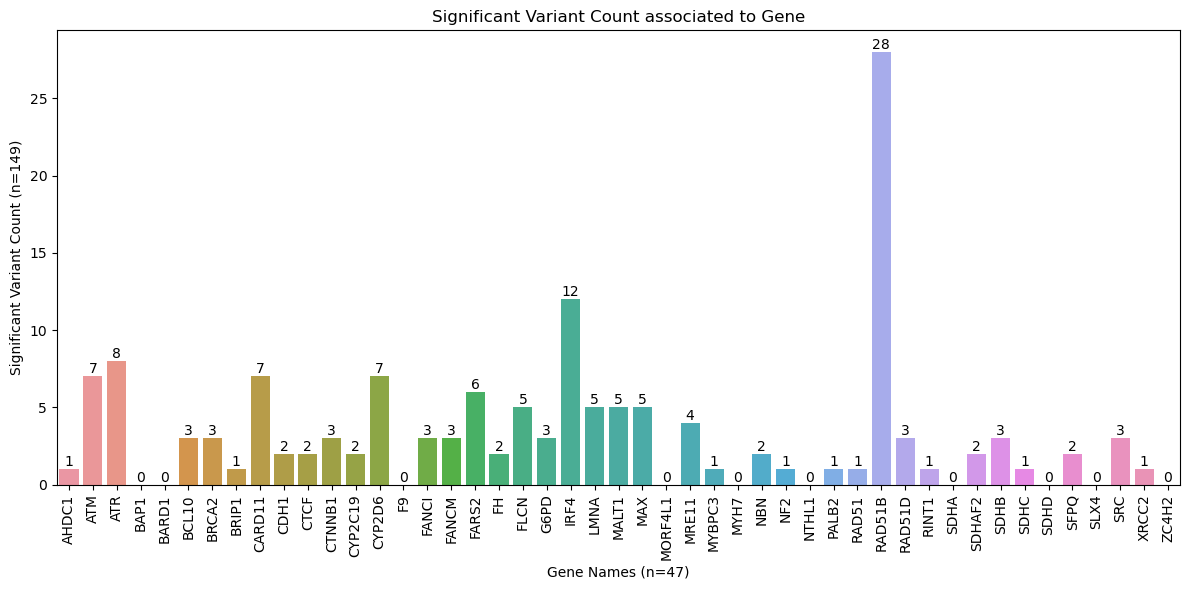

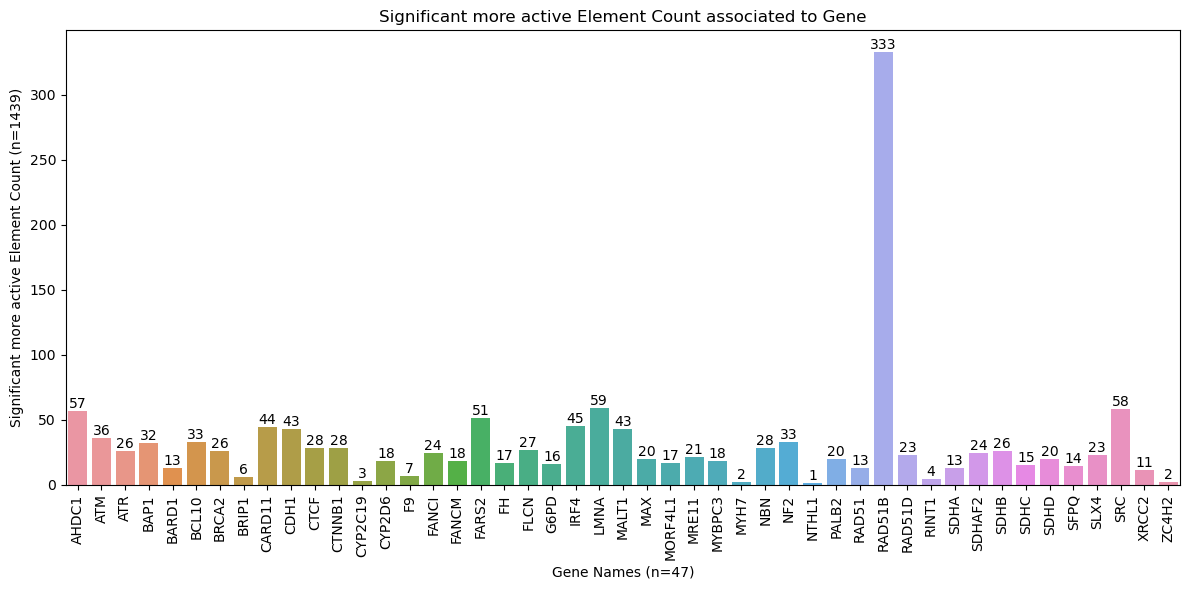

In [108]:
# gene_variant_info_table = significant_results[['gene_name', 'significant_variant_is_associated']]

output_name_gene_variant_table = os.path.join(config['files']['creating']['cava_analysis']['output_path'], 'gene_variant_association.tsv')
gene_variant_cava_table = pd.read_csv(output_name_gene_variant_table, sep="\t")
# read this variant table
gene_variant_cava_table

# # Variants make size table: number of significant variants per gene
# gene_name_significant_variant_associated = gene_variant_cava_table.groupby('gene_name').size().reset_index(name='significant_variant_count')

# # Elements make size table: Number of significant elements per gene
cava_element_to_gene_number = cava_element_analysis_result.groupby('gene_name').size().reset_index(name='number_of_elements')
cava_element_to_gene_number
gene_name_significant_element_associated = significant_cava_element_analysis_result.groupby('gene_name').size().reset_index(name='significant_element_count')
gene_name_significant_element_associated;

# combine the elements
gene_name_element_df = cava_element_to_gene_number.merge(gene_name_significant_element_associated, on='gene_name', how='outer')
gene_name_element_df

# fill na with 0 of significant_element_count
gene_name_element_df['significant_element_count'] = gene_name_element_df['significant_element_count'].fillna(0)

# compute proportion of significant_elements
gene_name_element_df['proportion_of_significant_elements'] = gene_name_element_df['significant_element_count'] / gene_name_element_df['number_of_elements']

# combine elements and variants
gene_name_significant_df = gene_name_element_df.merge(gene_variant_cava_table, on='gene_name', how='outer')
gene_name_significant_df;
# plot them
variant_output_path = os.path.join(config['files']['creating']['cava_analysis']['output_path'], 'significant_variants_associated_to_cava_genes_by_distance.png')
element_output_path = os.path.join(config['files']['creating']['cava_analysis']['output_path'], 'significant_elements_associated_to_cava_genes_by_distance.png')
# element_all_output_path = os.path.join(config['files']['creating']['cava_analysis']['output_path'], 'Number_of_elements_associated_to_cava_genes_by_distance.png')
plot_significant_count_per_gene(gene_name_significant_df, count_column_name='significant_variant_count', type_of_count='Variant', output_path=variant_output_path)
plot_significant_count_per_gene(gene_name_significant_df, count_column_name='significant_element_count', type_of_count='more active Element', output_path=element_output_path)
# plot_significant_count_per_gene(gene_name_significant_df, count_column_name='number_of_elements', type_of_count='more active Element', output_path=element_all_output_path)


# # Combine them
# gene_name_significant_counts = gene_name_significant_variant_associated.merge(gene_name_significant_element_associated, on='gene_name', how='outer')
# gene_name_significant_counts




##### Plot number of active elements per cava gene

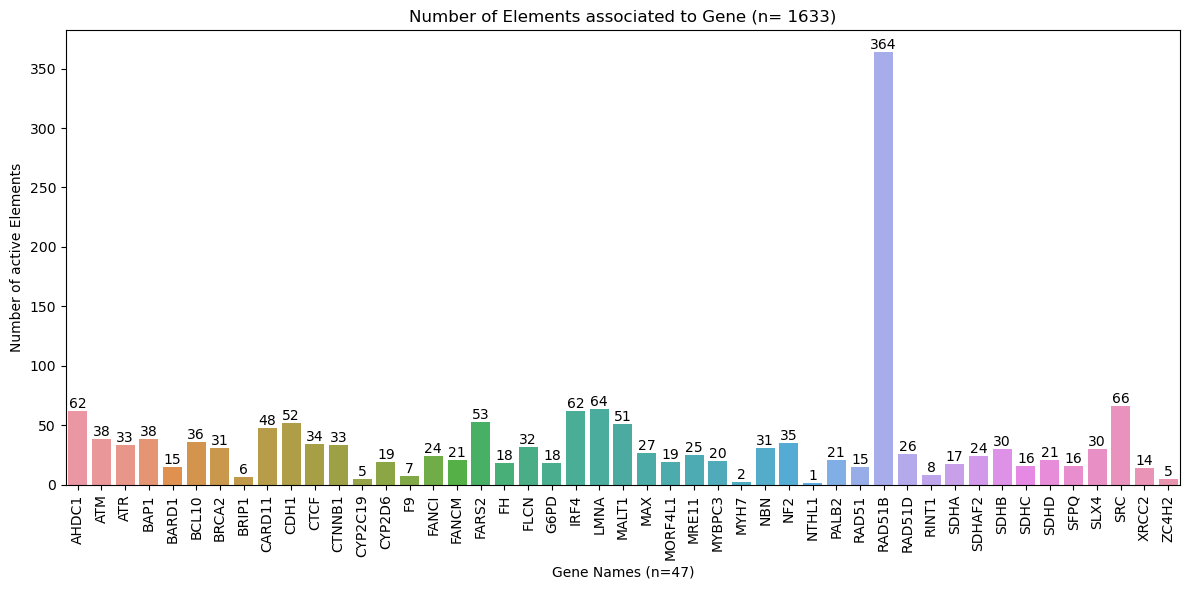

In [73]:
# plot_significant_count_per_gene(gene_name_significant_df, count_column_name='number_of_elements', type_of_count='more active Element', output_path=element_all_output_path)
# element_all_output_path =


import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
gene_name_element_df
output_path = os.path.join(config['files']['creating']['cava_analysis']['output_path'], 'Number_of_elements_associated_to_cava_genes_by_distance.png')
count_column_name='number_of_elements'
# Assuming your data is in a DataFrame called 'df'
# If it's not, you can create it like this:
# df = pd.DataFrame({'gene_name': [...], count_column_name: [...]})

# Sort the DataFrame by count_column_name in descending order
df_sorted = gene_name_significant_df.sort_values('gene_name', ascending=True)

# Create the bar plot
plt.figure(figsize=(12, 6))
plot = sns.barplot(x='gene_name', y=count_column_name, data=df_sorted)

# Customize the plot
plt.xlabel(f'Gene Names (n={df_sorted["gene_name"].nunique()})')
plt.ylabel(f'Number of active Elements')
plt.title(f'Number of Elements associated to Gene (n= {int(df_sorted["number_of_elements"].sum())})')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability

# Add value labels on top of each bar
for i, v in enumerate(df_sorted[count_column_name]):
    plt.text(i, v, str(int(v)), ha='center', va='bottom')

# Adjust layout and display the plot
plt.tight_layout()

fig = plot.get_figure()
# store to path
if output_path != None:
    fig.savefig(output_path)
plt.show()

##### Plot proporion of significant elements

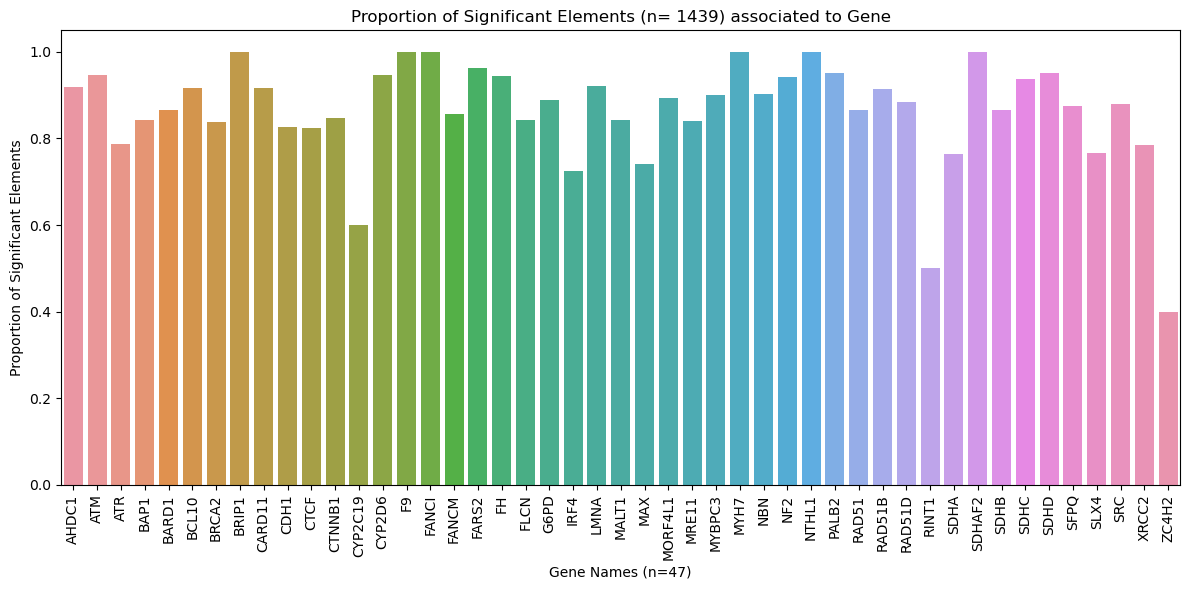

In [46]:
# plot proportion of significant elements
# plot_significant_count_per_gene(gene_name_element_df, count_column_name='proportion_of_significant_elements', type_of_count='more active Element', output_path=output_path)

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
gene_name_element_df
output_path = os.path.join(config['files']['creating']['cava_analysis']['output_path'], 'proportion_of_significant_elements_per_gene.png')
count_column_name='proportion_of_significant_elements'
# Assuming your data is in a DataFrame called 'df'
# If it's not, you can create it like this:
# df = pd.DataFrame({'gene_name': [...], count_column_name: [...]})

# Sort the DataFrame by count_column_name in descending order
df_sorted = gene_name_element_df.sort_values('gene_name', ascending=True)

# Create the bar plot
plt.figure(figsize=(12, 6))
plot = sns.barplot(x='gene_name', y=count_column_name, data=df_sorted)

# Customize the plot
plt.xlabel(f'Gene Names (n={df_sorted["gene_name"].nunique()})')
plt.ylabel(f'Proportion of Significant Elements')
plt.title(f'Proportion of Significant Elements (n= {int(df_sorted["significant_element_count"].sum())}) associated to Gene')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability

# # Add value labels on top of each bar
# for i, v in enumerate(df_sorted[count_column_name]):
#     plt.text(i, v, str(round(v, 2)), ha='center', va='bottom')

# Adjust layout and display the plot
plt.tight_layout()

fig = plot.get_figure()
# store to path
if output_path != None:
    fig.savefig(output_path)
plt.show()


#### Combine Element and variants and investigate list of genes with significant results


In [109]:
# print number of genes with significant elements (significant_element_count > 0)
element_signficant_genes_list = list(gene_name_significant_df.loc[gene_name_significant_df['significant_element_count'] > 0]['gene_name'].unique())
element_genes_list = list(gene_name_significant_df.loc[gene_name_significant_df['number_of_elements'] > 0]['gene_name'].unique())
print('Number of genes with associated elements: ', len(element_genes_list)) # 47
print('Number of genes with significant elements: ', len(element_signficant_genes_list)) # 47

variant_significant_genes_list = list(gene_name_significant_df.loc[gene_name_significant_df['significant_variant_count'] > 0]['gene_name'].unique())
variant_genes_list = list(gene_name_significant_df.loc[gene_name_significant_df['number_of_variants'] > 0]['gene_name'].unique())

print('Number of genes with associated variants: ', len(variant_genes_list)) # 47
print('Number of genes with significant variants: ', len(variant_significant_genes_list)) # 37


# print overlap of variants and elements of the set of metadata genes
set_of_metadata_genes = set(unique_source_data_cava_genes)
print('Number of genes with meta data from Lea: ', len(set_of_metadata_genes)) # 52

# overlap with design genes
print('Number of genes associated to elements: ', len(set(element_genes_list).intersection(set_of_metadata_genes))) # 22
print('Number of genes associated to variants: ', len(set(variant_genes_list).intersection(set_of_metadata_genes))) # 22
set_of_genes_readout_with_lea_metadata = set(element_genes_list).intersection(variant_genes_list).intersection(set_of_metadata_genes) # 22
print('Set of genes associated to elements and variants: ', len(set_of_genes_readout_with_lea_metadata) ) # 22
# significant:
# Elements
set_of_genes_readout_significant_elements_with_lea_metadata = set(element_signficant_genes_list).intersection(set_of_metadata_genes)
print('Number of genes with significant elements: ', len(set_of_genes_readout_significant_elements_with_lea_metadata)) # 22
print('Set of genes with significant elements: ', set_of_genes_readout_significant_elements_with_lea_metadata) # 19
# Variants
set_of_genes_readout_significant_variants_with_lea_metadata = set(variant_significant_genes_list).intersection(set_of_metadata_genes)
print('Number of genes with significant variants: ', len(set_of_genes_readout_significant_variants_with_lea_metadata)) # 19
print('Set of genes with significant variants: ', set_of_genes_readout_significant_variants_with_lea_metadata) # 19



Number of genes with associated elements:  47
Number of genes with significant elements:  47
Number of genes with associated variants:  47
Number of genes with significant variants:  37
Number of genes with meta data from Lea:  52
Number of genes associated to elements:  22
Number of genes associated to variants:  22
Set of genes associated to elements and variants:  22
Number of genes with significant elements:  22
Set of genes with significant elements:  {'IRF4', 'BRCA2', 'RAD51D', 'FARS2', 'CYP2D6', 'RAD51B', 'CARD11', 'SFPQ', 'NBN', 'CYP2C19', 'CTCF', 'MALT1', 'BCL10', 'BRIP1', 'BARD1', 'PALB2', 'F9', 'SDHD', 'AHDC1', 'LMNA', 'XRCC2', 'G6PD'}
Number of genes with significant variants:  19
Set of genes with significant variants:  {'IRF4', 'BRCA2', 'RAD51D', 'FARS2', 'CYP2D6', 'RAD51B', 'CARD11', 'SFPQ', 'NBN', 'CYP2C19', 'CTCF', 'MALT1', 'BCL10', 'BRIP1', 'PALB2', 'XRCC2', 'AHDC1', 'LMNA', 'G6PD'}


#### Investigate differences in gene sets given with metadata and used for design + with readouts from MPRA
- check how many are missing 
- check how many of the green are within the significant elements and significant variants

In [112]:
# print overlap with green marked genes
print('Number of genes with significant elements and green marked: ', len(set(element_signficant_genes_list).intersection(green_in_table))) # 9
print('Number of genes with significant variants and green marked: ', len(set(variant_significant_genes_list).intersection(green_in_table))) # 7

# print list of green marked genes with significant elements
print('List of green marked genes with significant elements: ', set(element_signficant_genes_list).intersection(green_in_table)) # 9

# print list of green marked genes with significant variants
print('List of green marked genes with significant variants: ', set(variant_significant_genes_list).intersection(green_in_table)) # 7

# print overlap and subsets for variant and elements with significant effects (numbers and the sets itself)
print('Number of genes with significant elements and variants: ', len(set(element_signficant_genes_list).intersection(variant_significant_genes_list))) # 37
print('Set of genes with significant elements and variants: ', set(element_signficant_genes_list).intersection(variant_significant_genes_list))
print('Number of overlap of genes with significant elements and variants with green marked genes: ', len(set(element_signficant_genes_list).intersection(variant_significant_genes_list).intersection(green_in_table))) # 8
print('Set of genes with significant elements and variants with green marked genes: ', set(element_signficant_genes_list).intersection(variant_significant_genes_list).intersection(green_in_table)) # 10

print('Number of genes with significant elements but not variants: ', len(set(element_signficant_genes_list).difference(variant_significant_genes_list))) # 10
print('Set of genes with significant elements but not variants: ', set(element_signficant_genes_list).difference(variant_significant_genes_list))

print('Number of genes with significant variants but not elements: ', len(set(variant_significant_genes_list).difference(element_signficant_genes_list))) # 0
print('Set of genes with significant variants but not elements: ', set(variant_significant_genes_list).difference(element_signficant_genes_list))

# only elements with overlap of green marked genes not variants
print('Number of genes with significant elements but not variants and green marked: ', len(set(element_signficant_genes_list).difference(variant_significant_genes_list).intersection(green_in_table))) # 2
print('Set of genes with significant elements but not variants and green marked: ', set(element_signficant_genes_list).difference(variant_significant_genes_list).intersection(green_in_table))

# missing green marked genes from significant elements and variants
print('Set of green marked genes not in significant variant: ', set(green_in_table).difference(set(variant_significant_genes_list))) # 1
print('Set of green marked genes not in significant elements: ', set(green_in_table).difference(set(element_signficant_genes_list)))
print('Set of green marked genes not associated to elements: ', set(green_in_table).difference(set(element_genes_list)))


Number of genes with significant elements and green marked:  10
Number of genes with significant variants and green marked:  8
List of green marked genes with significant elements:  {'CYP2C19', 'CTCF', 'CARD11', 'BARD1', 'SFPQ', 'PALB2', 'RAD51D', 'F9', 'NBN', 'G6PD'}
List of green marked genes with significant variants:  {'CYP2C19', 'CTCF', 'CARD11', 'SFPQ', 'PALB2', 'RAD51D', 'NBN', 'G6PD'}
Number of genes with significant elements and variants:  37
Set of genes with significant elements and variants:  {'RAD51', 'IRF4', 'MAX', 'NF2', 'SDHAF2', 'BRCA2', 'FLCN', 'RAD51D', 'FARS2', 'FH', 'MRE11', 'ATM', 'CYP2D6', 'RAD51B', 'CARD11', 'SFPQ', 'ATR', 'CTNNB1', 'SDHC', 'NBN', 'FANCI', 'CYP2C19', 'CTCF', 'CDH1', 'MALT1', 'BCL10', 'MYBPC3', 'FANCM', 'BRIP1', 'SDHB', 'SRC', 'PALB2', 'XRCC2', 'AHDC1', 'LMNA', 'G6PD', 'RINT1'}
Number of overlap of genes with significant elements and variants with green marked genes:  8
Set of genes with significant elements and variants with green marked genes: 

##### Plot venn diagramm of genes associated to: 
- metadata lea 
- marked as green in the table
- associated gene list
- associated to elements
- associated to significant elements
- associated to variants
- associated to significant variants

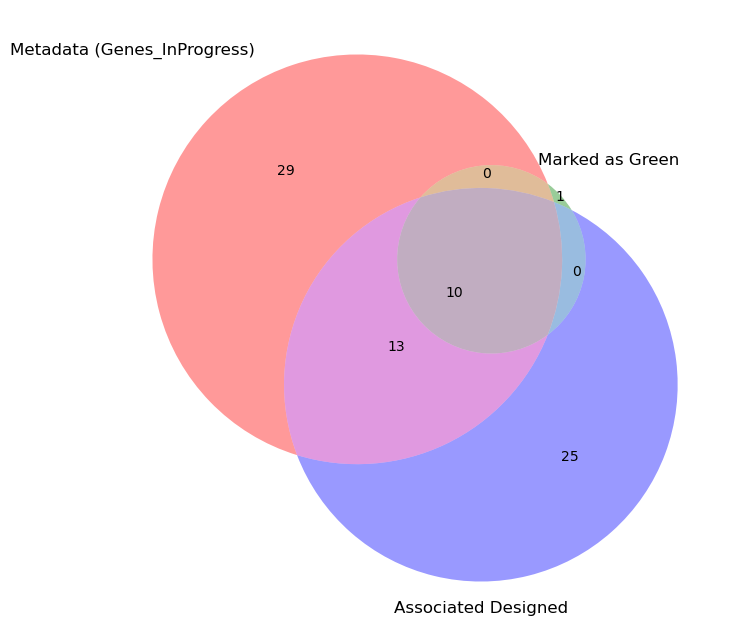

In [101]:
metadata_lea_gene_set = set(unique_source_data_cava_genes)
marked_as_green_gene_set = set(green_in_table)
associated_designed_gene_set = set(designed_gene_list['gene_name'].to_list())
associated_element_gene_set = set(element_genes_list)
significant_element_gene_set = set(element_signficant_genes_list)
associated_variant_gene_set = set(variant_genes_list)
significant_variant_gene_set = set(variant_significant_genes_list)

# # plot upset plot
# from upsetplot import from_contents, UpSet

# # Your sets
# sets = {
#     'Metadata (Genes_InProgress)': metadata_lea_gene_set,
#     'Marked as Green': marked_as_green_gene_set,
#     'Associated Designed': associated_designed_gene_set,
#     'Associated Element': associated_element_gene_set,
#     'Significant Element': significant_element_gene_set,
#     'Associated Variant': associated_variant_gene_set,
#     'Significant Variant': significant_variant_gene_set
# }

# # Create the UpSet plot
# upset = from_contents(sets)
# plot = UpSet(upset, sort_by='cardinality', show_percentages=False, show_counts=True)

# # Customize the plot
# plt.figure(figsize=(12, 8))
# plot.plot()
# plt.title('Intersection of Gene Sets')

# # Save the plot
# plt.savefig('gene_sets_upset_plot.png', dpi=300, bbox_inches='tight')
# # plt.close()
# plt.show()


# plot venn diagram
from matplotlib_venn import venn3

# Create the Venn diagram
plt.figure(figsize=(12, 8))

venn = venn3([metadata_lea_gene_set, marked_as_green_gene_set, associated_designed_gene_set],('Metadata (Genes_InProgress)', 'Marked as Green', 'Associated Designed'))




In [ ]:
unique_genes_designed_cava_elements = list(cava_element_analysis_result['gene_name'].unique()) # all except for one gene has an element result
print(len(unique_genes_designed_cava_elements)) # 47
cava_element_analysis_result['gene_name'].shape[0] # 1633 # 47 (unique)

In [59]:
# what is the overlap of the designed vs source and what is additional in either of the two groups?
unique_source_data_cava_genes_set = set(unique_source_data_cava_genes)

unique_genes_designed_cava_elements_set = set(unique_genes_designed_cava_elements)

# overlap
overlap_metadata_designed_gene_set = unique_source_data_cava_genes_set.intersection(unique_genes_designed_cava_elements_set)

# only in source_data
only_in_metadata = unique_source_data_cava_genes_set - unique_genes_designed_cava_elements_set
# {'ARAF',
#  'ATRIP',
#  'BRAF',
#  'CRAF',
#  'DYNC1H1',
#  'EGFR',
#  'EHMT1',
#  'ERBB2 (HER2)',
#  'GRB2',
#  'GTF2H1',
#  'KRAS',
#  'KSR1',
#  'KSR2',
#  'LZTR1',
#  'MEK1',
#  'MEK2',
#  'MET',
#  'MRAS',
#  'MRE11A',
#  'MRG15',
#  'PIK3CA',
#  'RAD50',
#  'RET',
#  'SHOC2',
#  'SHP2',
#  'SMARCA4',
#  'SOS1',
#  'SOS2',
#  'TRIO',
#  'TSC2'}
# only in designed cava
only_in_design_gene_set = unique_genes_designed_cava_elements_set - unique_source_data_cava_genes_set
only_in_design_gene_set
# {'ATM',
#  'ATR',
#  'BAP1',
#  'CDH1',
#  'CTNNB1',
#  'FANCI',
#  'FANCM',
#  'FH',
#  'FLCN',
#  'MAX',
#  'MORF4L1',
#  'MRE11',
#  'MYBPC3',
#  'MYH7',
#  'NF2',
#  'NTHL1',
#  'RAD51',
#  'RINT1',
#  'SDHA',
#  'SDHAF2',
#  'SDHB',
#  'SDHC',
#  'SLX4',
#  'SRC',
#  'ZC4H2'}

{'ATM',
 'ATR',
 'BAP1',
 'CDH1',
 'CTNNB1',
 'FANCI',
 'FANCM',
 'FH',
 'FLCN',
 'MAX',
 'MORF4L1',
 'MRE11',
 'MYBPC3',
 'MYH7',
 'NF2',
 'NTHL1',
 'RAD51',
 'RINT1',
 'SDHA',
 'SDHAF2',
 'SDHB',
 'SDHC',
 'SLX4',
 'SRC',
 'ZC4H2'}

In [60]:
overlap_metadata_designed_gene_set

{'AHDC1',
 'BARD1',
 'BCL10',
 'BRCA2',
 'BRIP1',
 'CARD11',
 'CTCF',
 'CYP2C19',
 'CYP2D6',
 'F9',
 'FARS2',
 'G6PD',
 'IRF4',
 'LMNA',
 'MALT1',
 'NBN',
 'PALB2',
 'RAD51B',
 'RAD51D',
 'SDHD',
 'SFPQ',
 'XRCC2'}

In [61]:
[x for x in green_in_table if not x in overlap_metadata_designed_gene_set] # ['C6PD', 'TSC2']

['C6PD', 'TSC2']

In [ ]:
# check if anything is in green set: (these are according to the excel sheet analysed by the pillar project)
[x for x in only_in_metadata if x in green_in_table]

In [31]:
cava_element_metadata_source_merge = cava_element_analysis_result.merge(cava_gene_list_source_df, left_on='gene_name', right_on='Gene', how='left')
cava_element_metadata_source_matched = cava_element_metadata_source_merge.loc[~cava_element_metadata_source_merge['Source'].isna()]
cava_element_metadata_source_matched # 997

,logFC,AveExpr,t,P.Value,adj.P.Val,variant_id,tmp_label,all,is_signficant,activating_effect,...,is_signiciant_and_random_activating,is_signiciant_and_neuro_repressing,is_signiciant_and_cardiac_repressing,is_signiciant_and_cava_repressing,is_signiciant_and_random_repressing,Gene,Assay,Prod Phase,Status,Source
0,0.827013,-0.121708,39.209423,7.912784e-208,1.020002e-204,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,cardiac_neuro_cava_random,True,True,True,...,False,False,False,False,False,RAD51B,SGE,add to pilot list,0%,ACMG73/HBOC
1,0.604801,-0.354815,32.913486,6.611266e-164,4.648521e-161,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,cardiac_neuro_cava_random,True,True,True,...,False,False,False,False,False,RAD51B,SGE,add to pilot list,0%,ACMG73/HBOC
2,1.225108,0.270987,31.239770,6.742493e-142,3.067570e-139,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,cardiac_neuro_cava_random,True,True,True,...,False,False,False,False,False,CYP2D6,VAMP-seq,pilot in TC,50%,CPIC
4,1.024381,0.076592,27.265612,8.965647e-117,2.418952e-114,cardiac_neuro_cava_random:REF_BCL10|ENSG000001...,cardiac_neuro_cava_random,True,True,True,...,False,False,False,False,False,BCL10,immuno-SGE,TC,15%,immune disease
7,0.367637,-0.581825,24.945044,1.299724e-107,2.741590e-105,cardiac_neuro_cava_random:REF_IRF4|ENSG0000013...,cardiac_neuro_cava_random,True,True,True,...,False,False,False,False,False,IRF4,immuno-SGE,Pilot and design,6%,IGVF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1627,-0.921744,-1.902358,0.000000,9.996896e-01,1.000000e+00,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,cardiac_neuro_cava_random,True,False,False,...,False,False,False,False,False,RAD51B,SGE,add to pilot list,0%,ACMG73/HBOC
1628,-0.944633,-1.864476,0.000000,9.997317e-01,1.000000e+00,cardiac_neuro_cava_random:MALT1|ENSG0000017217...,cardiac_neuro_cava_random,True,False,False,...,False,False,False,False,False,MALT1,immuno-SGE,design,5%,immune disease
1629,-0.936843,-1.867950,0.000000,9.999127e-01,1.000000e+00,cardiac_neuro_cava_random:REF_BRCA2|ENSG000001...,cardiac_neuro_cava_random,True,False,False,...,False,False,False,False,False,BRCA2,SGE,Bioinformatics,95%,ACMG73
1630,-0.905776,-1.866620,0.000000,9.999891e-01,1.000000e+00,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,cardiac_neuro_cava_random,True,False,False,...,False,False,False,False,False,RAD51B,SGE,add to pilot list,0%,ACMG73/HBOC


#### Tried to plot significant numbers with upset plot

In [22]:
# # plot a upset plot of the results: groups are all_elements, significant_elements, significant_activating_elements, significant_repressing_elements
# import matplotlib.pyplot as plt
# from upsetplot import generate_data, UpSet
# group_columns = ['all', 'is_signficant', 'is_signficant_and_activating', 'is_signficant_and_repressing']

# # using membership:
# membershipds = element_analysis_r_result.apply(lambda row: [col for col in group_columns if row[col]], axis=1)
# # Create UpSet data from memberships
# upset_data = from_memberships(memberships)

# # Create UpSet plot
# upset = UpSet(upset_data)
# upset.plot()

# no names of the groups

In [23]:
membershipds

NameError: name 'membershipds' is not defined

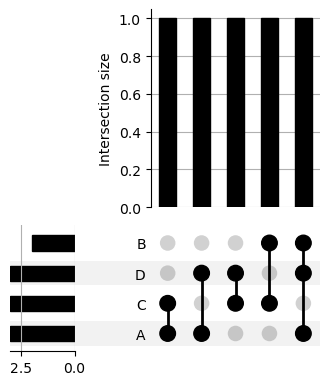

In [ ]:
from upsetplot import UpSet, from_memberships

# Sample DataFrame
data = {
    'A': [1, 1, 0, 0, 1],
    'B': [1, 0, 1, 0, 0],
    'C': [0, 1, 1, 1, 0],
    'D': [1, 0, 0, 1, 1]
}

df = pd.DataFrame(data)

# Create a list of memberships
memberships = df.apply(lambda row: [col for col in df.columns if row[col]], axis=1)

# Create UpSet data from memberships
upset_data = from_memberships(memberships)

# Create UpSet plot
upset = UpSet(upset_data)
upset.plot()

# Show the plot
plt.show()

In [ ]:
memberships

0    [A, B, D]
1       [A, C]
2       [B, C]
3       [C, D]
4       [A, D]
dtype: object

### Playground with pia treat understanding

In [ ]:
# read the table in: /home/kisa/coding/80K_MPRA/element_analysis_output/bc_mpralm_negative_neuron_NP_vs_tested_elements_right_side_no_alt.tsv
element_negative_neuron_right_sided_no_alt = pd.read_csv('/home/kisa/coding/80K_MPRA/element_analysis_output/bc_mpralm_negative_neuron_NP_vs_tested_elements_right_side_no_alt.tsv', sep="\t")
element_negative_neuron_right_sided_no_alt


,logFC,AveExpr,t,P.Value,adj.P.Val,variant_id
0,1.651677,0.708101,58.698986,0.0,0.0,cardiac_neuro_cava_random:RBM20|ENSG0000020386...
1,2.072247,1.128871,65.046968,0.0,0.0,cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...
2,1.852506,0.898595,62.907945,0.0,0.0,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...
3,1.765497,0.798857,61.935384,0.0,0.0,cardiac_neuro_cava_random:RERE|ENSG00000142599...
4,1.827335,0.859263,58.887183,0.0,0.0,cardiac_neuro_cava_random:TCF4|ENSG00000196628...
...,...,...,...,...,...,...
22908,-0.969547,-1.918135,0.000000,1.0,1.0,cardiac_neuro_cava_random:REF_GNAI1|ENSG000001...
22909,-1.001650,-1.934446,0.000000,1.0,1.0,cardiac_neuro_cava_random:REF_CREBBP|ENSG00000...
22910,-1.010178,-1.963804,0.000000,1.0,1.0,cardiac_neuro_cava_random:NCOA1|ENSG0000008467...
22911,-0.983895,-1.937132,0.000000,1.0,1.0,cardiac_neuro_cava_random:NLGN4X|ENSG000001469...


In [ ]:
significant_negativeNeuron = element_negative_neuron_right_sided_no_alt.loc[element_negative_neuron_right_sided_no_alt['adj.P.Val']<0.05]
significant_negativeNeuron

In [ ]:
# get log cutoff: min of positive values and max of negative values
log_cutoff_positive_NP = significant_negativeNeuron['logFC'].min()

print(log_cutoff_positive_NP)

-0.576007399021166


In [ ]:
# read scrambled neagtive neuron both sided no alt /home/kisa/coding/80K_MPRA/element_analysis_output/bc_mpralm_MK_scrambled_vs_tested_elements_both_sided_no_alt.tsv
element_scrambled_both_sided_no_alt = pd.read_csv('/home/kisa/coding/80K_MPRA/element_analysis_output/bc_mpralm_MK_scrambled_vs_tested_elements_both_sided_no_alt.tsv', sep="\t")
significant_scrambled = element_scrambled_both_sided_no_alt.loc[element_scrambled_both_sided_no_alt['adj.P.Val']<0.05]
significant_scrambled


,logFC,AveExpr,t,P.Value,adj.P.Val,variant_id
0,2.299629,2.349961,43.326750,1.199842e-164,2.783992e-160,cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...
1,2.041801,2.089708,38.439004,4.285810e-153,4.972182e-149,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...
2,2.060117,2.114754,36.145311,1.786444e-143,1.381695e-139,cardiac_neuro_cava_random:TCF4|ENSG00000196628...
3,1.952940,2.013103,36.038392,5.321837e-143,3.087065e-139,cardiac_neuro_cava_random:RERE|ENSG00000142599...
4,1.791744,1.837473,33.796753,6.380075e-133,2.960738e-129,cardiac_neuro_cava_random:RBM20|ENSG0000020386...
...,...,...,...,...,...,...
9091,-1.300292,-1.184862,-3.232237,6.990390e-04,4.621026e-02,cardiac_neuro_cava_random:RERE|ENSG00000142599...
9092,-1.384864,-1.261588,-3.239341,7.040745e-04,4.641091e-02,cardiac_neuro_cava_random:REF_NTRK2|ENSG000001...
9093,-1.437437,-1.318091,-3.244117,7.105616e-04,4.670584e-02,cardiac_neuro_cava_random:SRCAP|ENSG0000008060...
9094,-1.523282,-1.401097,-3.236370,7.390053e-04,4.843825e-02,cardiac_neuro_cava_random:PIGB|ENSG00000069943...


In [ ]:
significant_scrambled['is_positive'] = significant_scrambled['logFC'] > 0
significant_scrambled['is_negative'] = significant_scrambled['logFC'] < 0
# get log cutoff: min of positive values and max of negative values
log_cutoff_positive = significant_scrambled.loc[significant_scrambled['is_positive'], 'logFC'].min()
log_cutoff_negative = significant_scrambled.loc[significant_scrambled['is_negative'], 'logFC'].max()

print(log_cutoff_positive)
print(log_cutoff_negative)

0.31988005240937
-1.21437417281276


/tmp/ipykernel_24594/2732440937.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_scrambled['is_positive'] = significant_scrambled['logFC'] > 0
/tmp/ipykernel_24594/2732440937.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_scrambled['is_negative'] = significant_scrambled['logFC'] < 0


### Gene sets: in design and from E2G
- ids of the regions we tested 
- ids of genes we have in the headers 
- ids of genes predicted to be affected by the regions

In [5]:
# what is the proportion of neuro elements which are open in neuro
meta_data_file = pd.read_csv(config['files']['creating']['datafreeze_table'], sep="\t", low_memory=False)

# read columns from tsv
# list columns col_variant_class, col_variant_pos, col_SPDI, col_allele,
list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]
# Apply the safe_eval function to the specified columns
for col in list_columns:
    meta_data_file[col] = meta_data_file[col].apply(safe_eval)

In [24]:
print('Number of different sequences: ',meta_data_file.shape[0])
without_alt = meta_data_file.loc[~meta_data_file['allele'].apply(hf.is_alternative)]
print("Number of reference sequences: ", without_alt.shape[0])

# show all rows of without_alt with duplicates in tmp_region_id
without_alt[without_alt.duplicated(subset='tmp_region_id', keep=False)][['header', 'chr', 'start', 'end']].to_csv('/home/kisa/coding/80K_MPRA/e2g_analysis_output/screen_regions/duplicated_regions_in_reference.tsv', sep="\t", index=False)

# remove duplicated regions
without_alt_deduplicated = without_alt.drop_duplicates(subset='tmp_region_id')
print('Number of different regions: ', without_alt_deduplicated.shape[0]) # 27199

# get open chromatin in neuro
without_alt_deduplicated['tmp_open_neuro'] = without_alt_deduplicated['tmp_open_NGN2_WTC11_NP_screen_regions'] | without_alt_deduplicated['tmp_open_NGN2_WTC11_NP'] | without_alt_deduplicated['tmp_open_h1_neuro_dnase_screen']
without_alt_deduplicated['tmp_open_neuro'].sum() # 2006

print('Proportion of neuro elements which are open in neuro: ', without_alt_deduplicated['tmp_open_neuro'].sum() / without_alt_deduplicated.shape[0]) # 0.0738



Number of different sequences:  73846
Number of reference sequences:  27472
Number of different regions:  27199
Proportion of neuro elements which are open in neuro:  0.0737527114967462


/tmp/ipykernel_1361839/2320085917.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  without_alt_deduplicated['tmp_open_neuro'] = without_alt_deduplicated['tmp_open_NGN2_WTC11_NP_screen_regions'] | without_alt_deduplicated['tmp_open_NGN2_WTC11_NP'] | without_alt_deduplicated['tmp_open_h1_neuro_dnase_screen']


In [ ]:
# add neuro_open_column